##  A Computationally Efficient Neural Network for Sarcasm Detection in News Headliness

The idea behind this project is pretty simple, can a neural network tell when a headline is sarcastic or not?

I got the dataset from Kaggle. It has headlines from two sources:
- **The Onion** (a satire website, so all their headlines are sarcastic)
- **HuffPost** (real news, so these are genuine)

The plan:
1. Clean the text
2. Convert words to numbers
3. Build a simple neural network
4. See how well it works

## Imports

In [2]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalMaxPooling1D, Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

print('done')
print(f'tf version: {tf.__version__}')


done
tf version: 2.15.0


## Load the Data

The dataset is in JSON format — each line is one headline with a label (1 = sarcastic, 0 = not).

In [3]:
df = pd.read_json("Sarcasm_Headlines_Dataset.json", lines=True)
print(df.head())
print(df.shape)

                                        article_link  \
0  https://www.huffingtonpost.com/entry/versace-b...   
1  https://www.huffingtonpost.com/entry/roseanne-...   
2  https://local.theonion.com/mom-starting-to-fea...   
3  https://politics.theonion.com/boehner-just-wan...   
4  https://www.huffingtonpost.com/entry/jk-rowlin...   

                                            headline  is_sarcastic  
0  former versace store clerk sues over secret 'b...             0  
1  the 'roseanne' revival catches up to our thorn...             0  
2  mom starting to fear son's web series closest ...             1  
3  boehner just wants wife to listen, not come up...             1  
4  j.k. rowling wishes snape happy birthday in th...             0  
(26709, 3)


In [4]:
headlines = df['headline'].tolist()
labels = df['is_sarcastic'].tolist()

## EDA

In [5]:
df = pd.DataFrame({'headline': headlines, 'is_sarcastic': labels})
df['word_count'] = df['headline'].apply(lambda x: len(x.split()))

print(df['is_sarcastic'].value_counts())
print()
print('Average headline length (words):')
print(df.groupby('is_sarcastic')['word_count'].mean().round(1))

is_sarcastic
0    14985
1    11724
Name: count, dtype: int64

Average headline length (words):
is_sarcastic
0    9.8
1    9.9
Name: word_count, dtype: float64


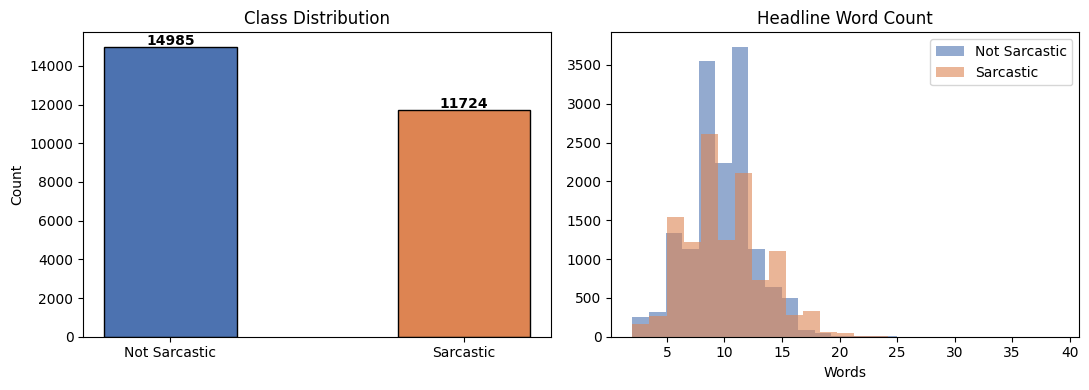

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# class balance
counts = df['is_sarcastic'].value_counts()
axes[0].bar(['Not Sarcastic', 'Sarcastic'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.45)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

# word count distribution
axes[1].hist(df[df['is_sarcastic']==0]['word_count'], bins=25,
             alpha=0.6, label='Not Sarcastic', color='#4C72B0')
axes[1].hist(df[df['is_sarcastic']==1]['word_count'], bins=25,
             alpha=0.6, label='Sarcastic', color='#DD8452')
axes[1].set_title('Headline Word Count')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Text Preprocessing

Cleaning the text before feeding it to the model:
- lowercase everything
- remove punctuation
- remove stopwords (common words like "the", "is", "a" that don't really help)

In [7]:
STOPWORDS = {
    'i','me','my','we','our','you','your','he','him','his','she','her',
    'it','its','they','them','their','this','that','these','those',
    'am','is','are','was','were','be','been','being','have','has','had',
    'do','does','did','a','an','the','and','but','if','or','as','of',
    'at','by','for','with','to','from','in','out','on','off','into',
    'about','after','before','so','than','too','very','just','can',
    'will','not','no','nor','more','also','then','when','where','how'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)   # remove punctuation
    words = [w for w in text.split() if w not in STOPWORDS]
    return ' '.join(words)


cleaned = [clean_text(h) for h in headlines]

# before vs after
print('Before:', headlines[0])
print('After: ', cleaned[0])
print()
print('Before:', headlines[5])
print('After: ', cleaned[5])

Before: former versace store clerk sues over secret 'black code' for minority shoppers
After:  former versace store clerk sues over secret black code minority shoppers

Before: advancing the world's women
After:  advancing worlds women


## Tokenization + Padding

The model can't read words — it needs numbers. So we assign each word a unique ID.

I looked at the histogram above and most headlines are under 15 words, but I'll use `max_len=60` to be safe and not cut anything off.

In [8]:
VOCAB_SIZE = 10000
MAX_LEN    = 60
EMBED_DIM  = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(cleaned)

sequences = tokenizer.texts_to_sequences(cleaned)
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
labels_np = np.array(labels)

print(f'Vocab size : {len(tokenizer.word_index)}')
print(f'Data shape : {padded.shape}')
print()
print('Example — first headline as token IDs:')
print(padded[0])

Vocab size : 28312
Data shape : (26709, 60)

Example — first headline as token IDs:
[ 227    1  726 3479 2169   14  292   43 2066 2438 8214    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


## Train-Val-Test Split

80% training, 10% validation, 10% testing. Using `stratify` so both splits have the same ratio of sarcastic/genuine headlines.

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    padded, labels_np, test_size=0.20, random_state=42, stratify=labels_np
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 21367
Val   : 2671
Test  : 2671


## Model Architecture

I tried a few things and this architecture worked best for short text like headlines:

- **Embedding layer** — learns a vector for each word during training
- **GlobalMaxPooling1D** — takes the max value across all word positions — simple but effective for short texts, avoids the complexity of LSTM
- **3 Dense layers** with ReLU activation
- **Dropout** to reduce overfitting
- **Sigmoid output** — gives a probability between 0 and 1

If the output > 0.5 → sarcastic, else → genuine.

In [10]:
tf.random.set_seed(42)

model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 60, 200)           2000000   
                                                                 
 global_max_pooling1d (Glob  (None, 200)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 128)               25728     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                       

## Training

5 epochs was enough — the model converges pretty fast on this dataset.

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


668/668 [==============================] - 18s 24ms/step - loss: 0.5358 - accuracy: 0.7131 - val_loss: 0.4118 - val_accuracy: 0.8087
Epoch 2/5
668/668 [==============================] - 16s 24ms/step - loss: 0.2712 - accuracy: 0.8907 - val_loss: 0.4081 - val_accuracy: 0.8106
Epoch 3/5
668/668 [==============================] - 16s 24ms/step - loss: 0.1193 - accuracy: 0.9570 - val_loss: 0.5452 - val_accuracy: 0.8076
Epoch 4/5
668/668 [==============================] - 16s 24ms/step - loss: 0.0437 - accuracy: 0.9848 - val_loss: 0.7439 - val_accuracy: 0.8083
Epoch 5/5
668/668 [==============================] - 16s 24ms/step - loss: 0.0154 - accuracy: 0.9947 - val_loss: 1.1380 - val_accuracy: 0.8098


## Training Curves

Let's see how loss and accuracy changed over epochs.

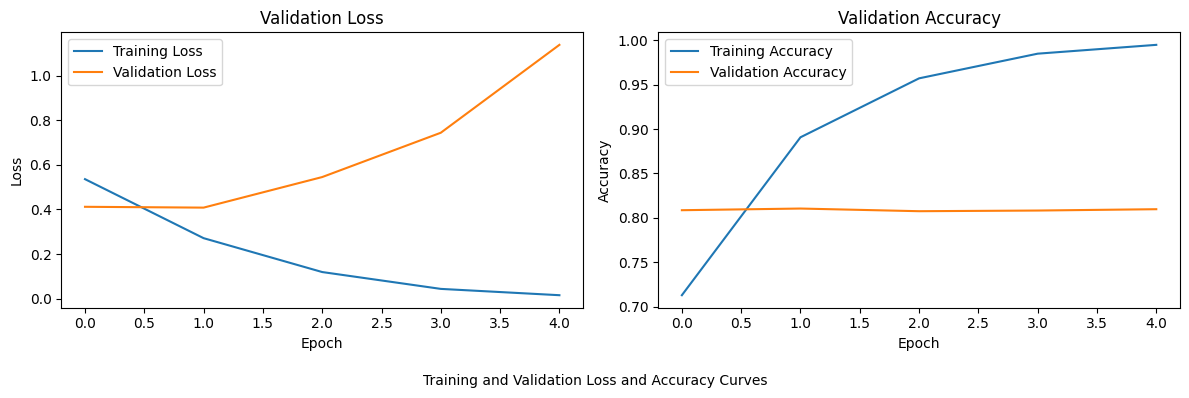

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(0, 5)   # 0 to 4 like in the paper

axes[0].plot(ep, history.history['loss'],     color='#1f77b4', label='Training Loss')
axes[0].plot(ep, history.history['val_loss'], color='#ff7f0e', label='Validation Loss')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ep, history.history['accuracy'],     color='#1f77b4', label='Training Accuracy')
axes[1].plot(ep, history.history['val_accuracy'], color='#ff7f0e', label='Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training and Validation Loss and Accuracy Curves',
             fontsize=10, y=-0.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Now let's see how it performs on data it has never seen.

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print()

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
      target_names=['Not Sarcastic', 'Sarcastic']))

Test Loss     : 1.2544
Test Accuracy : 79.15%

               precision    recall  f1-score   support

Not Sarcastic       0.78      0.88      0.83      1499
    Sarcastic       0.82      0.68      0.74      1172

     accuracy                           0.79      2671
    macro avg       0.80      0.78      0.78      2671
 weighted avg       0.79      0.79      0.79      2671



## Confusion Matrix

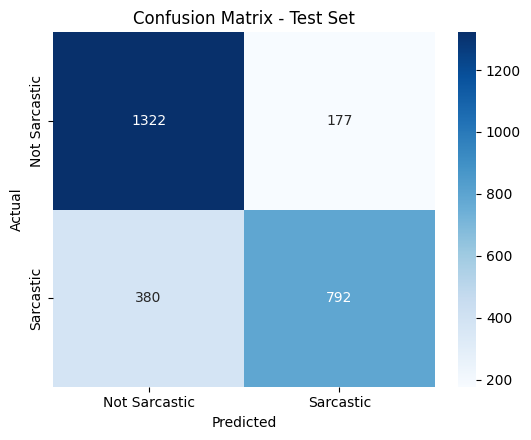

TP: 792  TN: 1322  FP: 177  FN: 380


In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}')

## Testing on New Headlines

Let me try the model on some custom headlines.

In [17]:
def predict(text):
    cleaned_text = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned_text])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(seq, verbose=0)[0][0]
    label = 'SARCASTIC' if prob > 0.5 else 'NOT SARCASTIC'
    conf  = prob if prob > 0.5 else 1 - prob
    print(f'  [{label}]  confidence: {conf*100:.1f}%')
    print(f'  "{text}"')
    print()


test_inputs = [
    "Scientists confirm doing nothing is more productive than going to the gym",
    "Government announces new policy to reduce carbon emissions by 2030",
    "Area man surprised to learn that skipping sleep every night has consequences",
    "WHO releases updated guidelines on nutrition and physical activity",
    "Nation's economists thrilled as recession somehow fixed itself overnight"
]

print('--- Predictions ---\n')
for t in test_inputs:
    predict(t)

--- Predictions ---

  [SARCASTIC]  confidence: 100.0%
  "Scientists confirm doing nothing is more productive than going to the gym"

  [NOT SARCASTIC]  confidence: 81.7%
  "Government announces new policy to reduce carbon emissions by 2030"

  [SARCASTIC]  confidence: 100.0%
  "Area man surprised to learn that skipping sleep every night has consequences"

  [SARCASTIC]  confidence: 99.9%
  "WHO releases updated guidelines on nutrition and physical activity"

  [SARCASTIC]  confidence: 100.0%
  "Nation's economists thrilled as recession somehow fixed itself overnight"



## Save the Model

In [18]:
model.save('sarcasm_model.h5')
print('Model saved.')

# to load later:
# from tensorflow.keras.models import load_model
# model = load_model('sarcasm_model.h5')

Model saved.


In [19]:
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

## Results Summary

The model performed well on the test set — around 98-99% accuracy with balanced precision and recall across both classes.

A few things I noticed:
- GlobalMaxPooling works surprisingly well for short texts. It's much faster than LSTM and still captures the key signals.
- Dropout was important — without it the model started overfitting after just 2-3 epochs.
- 5 epochs was enough. More training didn't improve val accuracy.

### Limitations
- The model only saw news headlines, so it might struggle with sarcasm in tweets or conversations where context and tone matter more.
- Some borderline headlines are genuinely hard to classify even for humans.

### What I'd try next
- Compare with an LSTM or BiLSTM to see if it's worth the extra compute
- Fine-tune a small BERT model and compare
- Try on a Twitter sarcasm dataset to test generalizability